# Analyse croisée : Nappe phréatique + Précipitations — Épisode EU hors de contrôle (2026)

## Contexte

Le SIBA a connu un épisode « réseau EU hors de contrôle » du **28 janvier 2026 au 25 février 2026**. Ce notebook croise les données de nappe phréatique (piézomètres de Blagon et Piraillan) avec les précipitations (station Cap-Ferret) pour déterminer la nature des eaux claires parasites responsables de cet épisode.

### ECPP vs ECPM : deux mécanismes distincts

- **ECPM (Eaux Claires Parasites Météoriques)** : infiltrations directement liées à la pluie (mauvais raccordements, regards non étanches). **Signature** : le réseau EU revient à la normale **quelques heures** après la cessation des précipitations.
- **ECPP (Eaux Claires Parasites Permanentes)** : infiltrations provenant de la **nappe phréatique** à travers les défauts d'étanchéité du réseau (joints, fissures, branchements). **Signature** : le réseau EU reste en surcharge **tant que la nappe est haute**, indépendamment de la pluie du moment.

### Hypothèses

- **H1 — Dominante ECPM** : l'épisode est causé par des précipitations exceptionnelles → le réseau devrait revenir à la normale rapidement après la fin des pluies
- **H2 — Dominante ECPP** : la nappe phréatique haute provoque des infiltrations permanentes → le réseau reste en surcharge même quand la pluie cesse
- **H3 — Vulnérabilité structurelle** : le réseau EU, situé sous le niveau de la nappe, est structurellement exposé aux ECPP pendant les périodes de nappe haute

### Période d'analyse

- **Période « hors de contrôle »** : 28/01/2026 → 25/02/2026
- **Contexte** : année 2025-2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from siba import (
    CURRENT_YEAR,
    PIEZOMETERS,
    fetch_nappe_multi_years,
    load_meteo_capferret,
    merge_nappe_pluie,
)

plt.style.use('seaborn-v0_8-whitegrid')

YEARS = range(2025, CURRENT_YEAR + 1)
DATE_MIN = '2025-01-01'

# Période "hors de contrôle"
HC_START = pd.Timestamp('2026-01-28')
HC_END = pd.Timestamp('2026-02-25')

## 1. Chargement des données de nappe phréatique

Récupération via l'API Hub'eau des chroniques piézométriques pour :
- **Blagon** (Lanton) — code BSS `08262X0290/F`
- **Piraillan** (Lège-Cap-Ferret) — code BSS `08257X0086/F`

In [2]:
nappe_data = {}
for p in PIEZOMETERS:
    nappe_data[p['name']] = fetch_nappe_multi_years(
        p['code_bss'], p['name'], years=YEARS
    )

# Aperçu
for name, df in nappe_data.items():
    if len(df) > 0:
        print(f"\n{name} : {df['date_mesure'].min().date()} → {df['date_mesure'].max().date()}")
        print(f"  Profondeur : {df['profondeur_nappe'].min():.2f} m → {df['profondeur_nappe'].max():.2f} m")

Récupération multi-années : Blagon (Lanton) (08262X0023/F)
  Cache → Blagon (Lanton) (08262X0023/F) année 2026 (âge 1.4 h)
  Total : 618 mesures (2025-01-01 → 2026-09-11)
Récupération multi-années : Piraillan (Lège-Cap-Ferret) (08257X0086/F)
  Cache → Piraillan (Lège-Cap-Ferret) (08257X0086/F) année 2026 (âge 1.5 h)
  Total : 619 mesures (2025-01-01 → 2026-09-11)

Blagon (Lanton) : 2025-01-01 → 2026-09-11
  Profondeur : 0.78 m → 2.77 m

Piraillan (Lège-Cap-Ferret) : 2025-01-01 → 2026-09-11
  Profondeur : 2.53 m → 4.28 m


## 2. Chargement des données de précipitations

Données Météo-France pour le département de la Gironde (33), filtrées sur la station **Cap-Ferret**.

In [3]:
df_cf = load_meteo_capferret(date_min=DATE_MIN)

print(f"  RR max journalier : {df_cf['RR'].max():.1f} mm")
print(f"  RR7 max : {df_cf['SLIDING_RR7'].max():.1f} mm")

  Archive figée : /home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_previous-1950-2024_RR-T-Vent.csv.gz


  À jour (1.3 h) : /home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_latest-2025-2026_RR-T-Vent.csv.gz
Fichiers CSV météo : ['/home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_1842-1949_RR-T-Vent.csv', '/home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_latest-2025-2026_RR-T-Vent.csv', '/home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_previous-1950-2024_RR-T-Vent.csv']


Cap-Ferret : 2025-01-01 → 2026-09-11  (619 jours)
  RR max journalier : 40.4 mm
  RR7 max : 103.4 mm


## 3. Harmonisation temporelle

Resampling des données de nappe en fréquence journalière et fusion avec les précipitations.

In [4]:
df_merged = merge_nappe_pluie(nappe_data, df_cf, date_min=DATE_MIN)

# Étendue réelle des données, pour les titres des graphiques
PERIODE = f"{df_merged.index.min().year}-{df_merged.index.max().year}"

print(f"DataFrame fusionné : {len(df_merged)} jours")
print(f"Colonnes : {list(df_merged.columns)}")
print("\nDonnées manquantes :")
print(df_merged.isnull().sum())
print("\nAperçu :")
df_merged.tail(10)

DataFrame fusionné : 619 jours
Colonnes : ['Blagon', 'Piraillan', 'RR', 'SLIDING_RR7']

Données manquantes :
Blagon         0
Piraillan      0
RR             0
SLIDING_RR7    0
dtype: int64

Aperçu :


,Blagon,Piraillan,RR,SLIDING_RR7
date,,,,
2026-09-02,2.77,4.22,0.0,8.9
2026-09-03,2.77,4.21,0.0,0.4
2026-09-04,2.77,4.21,0.0,0.2
2026-09-05,2.77,4.22,0.0,0.2
2026-09-06,2.77,4.24,0.0,0.0
2026-09-07,2.77,4.25,0.0,0.0
2026-09-08,2.77,4.27,0.2,0.2
2026-09-09,2.77,4.27,0.2,0.4
2026-09-10,2.77,4.28,0.0,0.4


## 4. Visualisation 1 — Timeline nappe 2026

Évolution de la profondeur de nappe pour Blagon et Piraillan, avec mise en évidence de la période « hors de contrôle ».

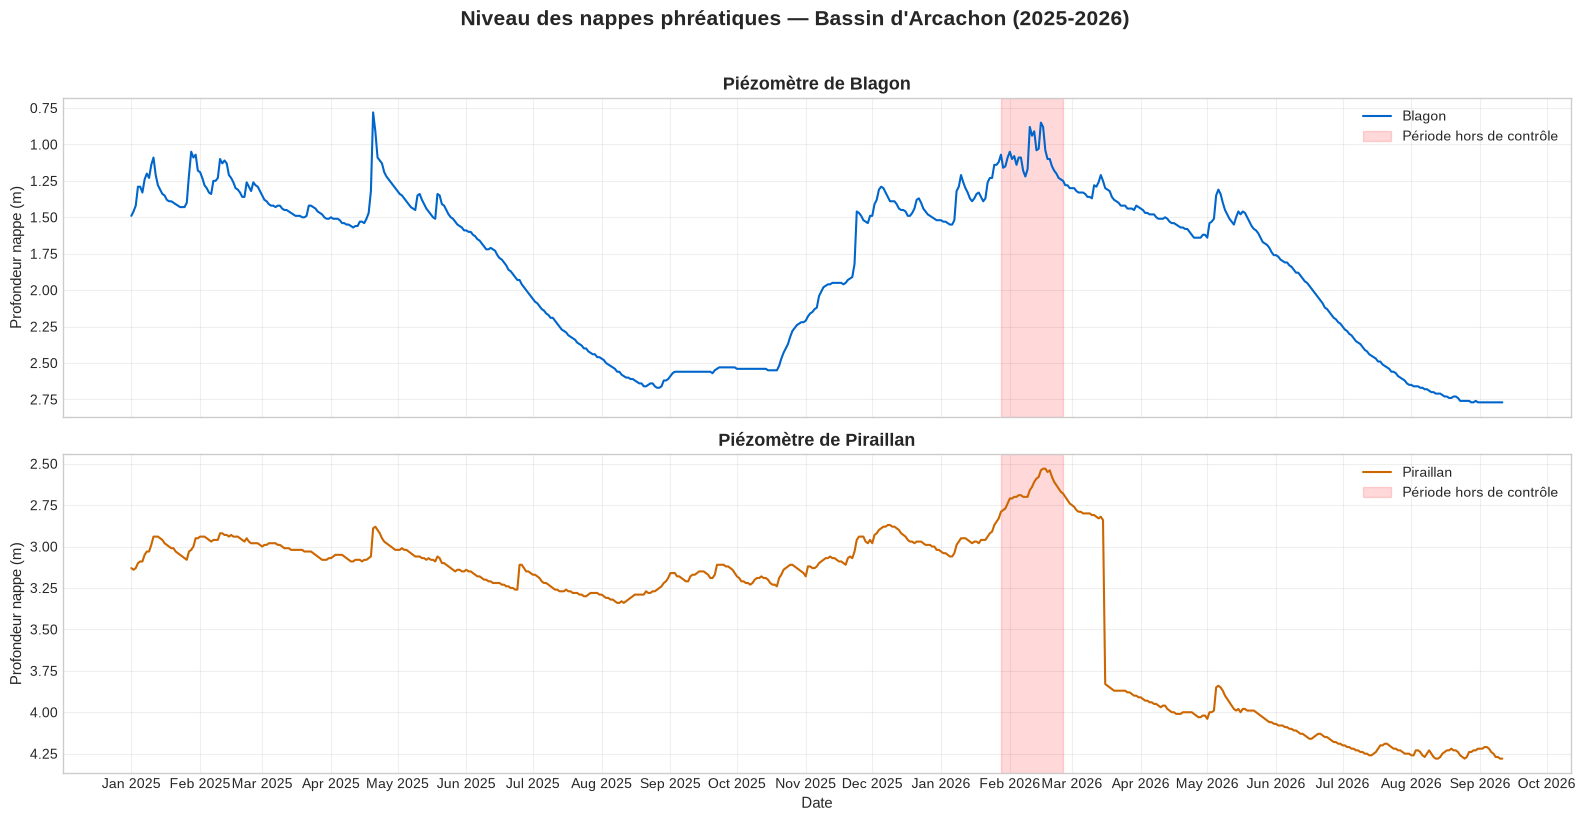

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

nappe_cols = [c for c in df_merged.columns if c not in ['RR', 'SLIDING_RR7']]
colors = ['#0066cc', '#cc6600']

for idx, col in enumerate(nappe_cols):
    ax = axes[idx]
    data = df_merged[col].dropna()
    ax.plot(data.index, data.values, linewidth=1.5, color=colors[idx], label=col)
    
    # Bande période hors de contrôle
    ax.axvspan(HC_START, HC_END, alpha=0.15, color='red', label='Période hors de contrôle')
    
    ax.set_ylabel('Profondeur nappe (m)', fontsize=11)
    ax.set_title(f'Piézomètre de {col}', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

axes[-1].set_xlabel('Date', fontsize=11)
fig.suptitle(f'Niveau des nappes phréatiques — Bassin d\'Arcachon ({PERIODE})',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Visualisation 2 — Timeline pluie 2026

Précipitations journalières et cumul glissant 7 jours à Cap-Ferret.

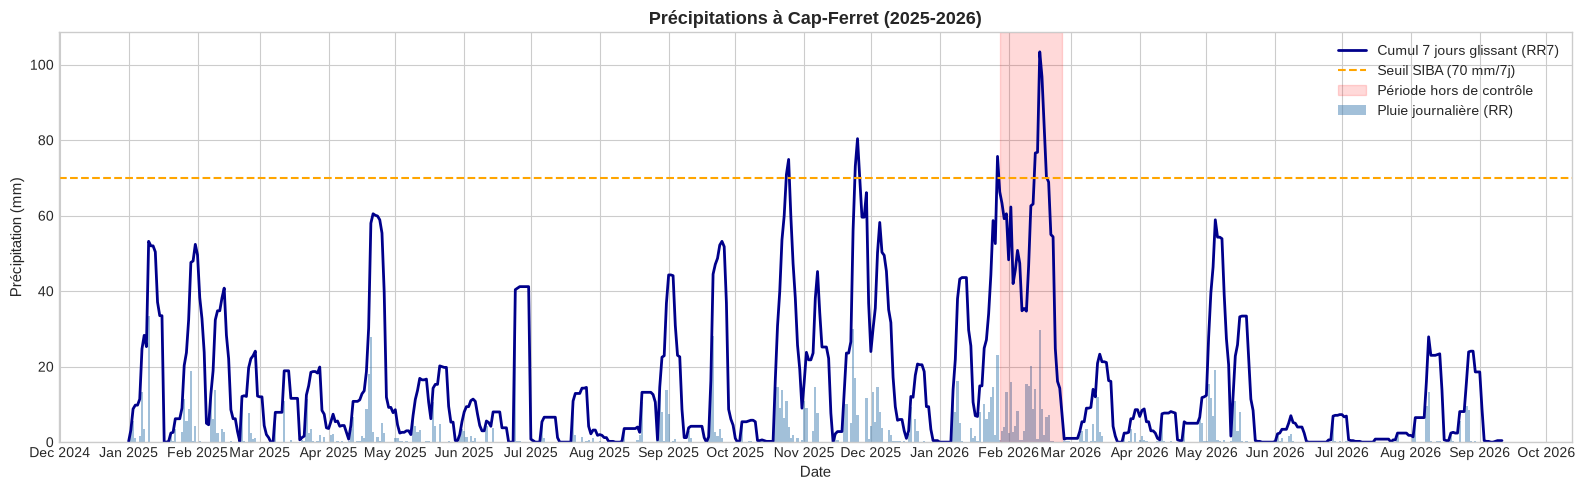

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))

# Barres RR journalier
ax.bar(df_merged.index, df_merged['RR'].fillna(0), width=1, alpha=0.5,
       color='steelblue', label='Pluie journalière (RR)')

# Courbe RR7 glissant
ax.plot(df_merged.index, df_merged['SLIDING_RR7'], color='darkblue',
        linewidth=2, label='Cumul 7 jours glissant (RR7)')

# Seuil SIBA 70 mm
ax.axhline(y=70, color='orange', linestyle='--', linewidth=1.5, label='Seuil SIBA (70 mm/7j)')

# Bande période hors de contrôle
ax.axvspan(HC_START, HC_END, alpha=0.15, color='red', label='Période hors de contrôle')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Précipitation (mm)', fontsize=11)
ax.set_title(f'Précipitations à Cap-Ferret ({PERIODE})', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.show()

## 6. Visualisation 3 — Overlay nappe + RR7

Superposition nappe (axe gauche) et cumul 7 jours (axe droit) pour visualiser les coïncidences temporelles.

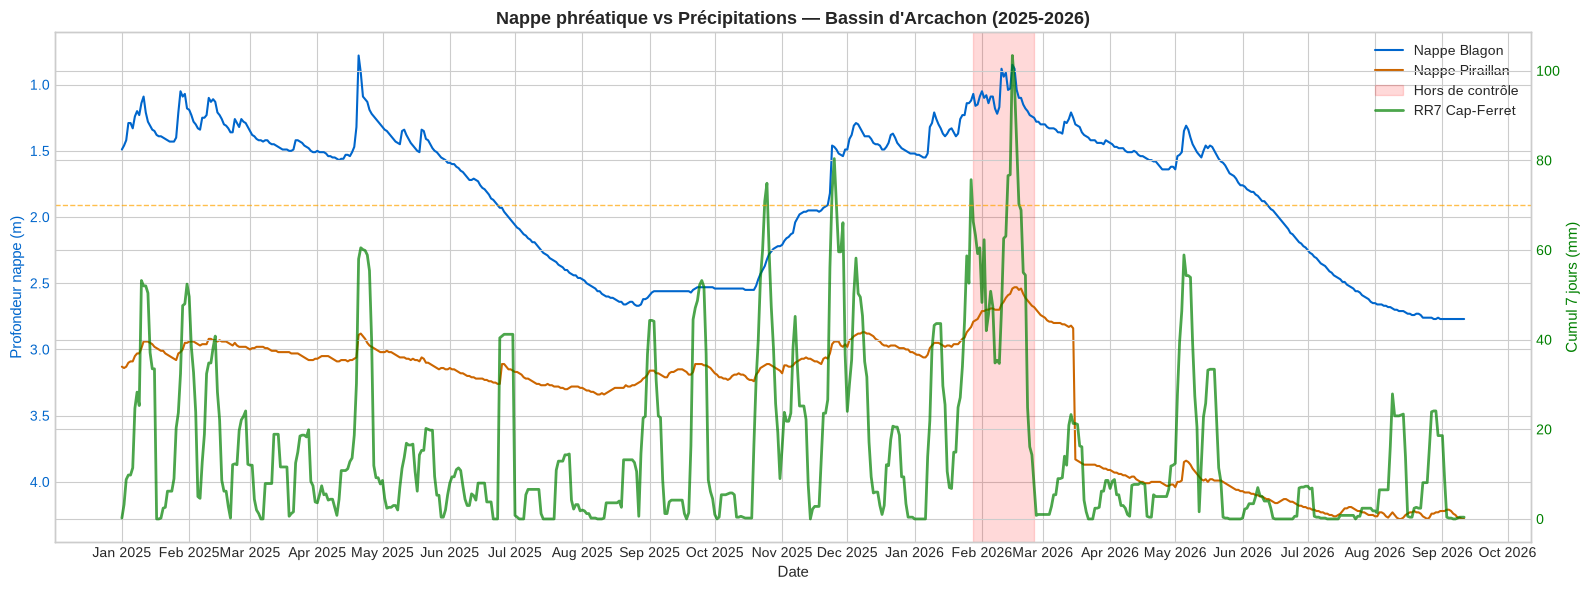

In [7]:
fig, ax1 = plt.subplots(figsize=(16, 6))

# Axe gauche : nappe
for col, color in zip(nappe_cols, colors):
    data = df_merged[col].dropna()
    ax1.plot(data.index, data.values, color=color, linewidth=1.5, label=f'Nappe {col}')
ax1.set_ylabel('Profondeur nappe (m)', fontsize=11, color='#0066cc')
ax1.invert_yaxis()
ax1.tick_params(axis='y', labelcolor='#0066cc')

# Axe droit : RR7
ax2 = ax1.twinx()
ax2.plot(df_merged.index, df_merged['SLIDING_RR7'], color='green',
         linewidth=2, alpha=0.7, label='RR7 Cap-Ferret')
ax2.axhline(y=70, color='orange', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_ylabel('Cumul 7 jours (mm)', fontsize=11, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Bande période hors de contrôle
ax1.axvspan(HC_START, HC_END, alpha=0.15, color='red', label='Hors de contrôle')

# Légendes combinées
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlabel('Date', fontsize=11)
ax1.set_title(f'Nappe phréatique vs Précipitations — Bassin d\'Arcachon ({PERIODE})',
              fontsize=13, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.show()

## 6b. Analyse ECPP vs ECPM — Réponse temporelle nappe vs pluie

**Argument clé** : si les infiltrations étaient de nature météorique (ECPM), le réseau reviendrait à la normale rapidement après la cessation des pluies. On compare ici les **temps de réponse** de la pluie (RR7) et de la nappe pour montrer l'inertie de la nappe — signature caractéristique des ECPP.

On identifie les « fenêtres sèches » (périodes où RR7 diminue significativement) et on observe si la nappe suit le même rythme de décroissance.

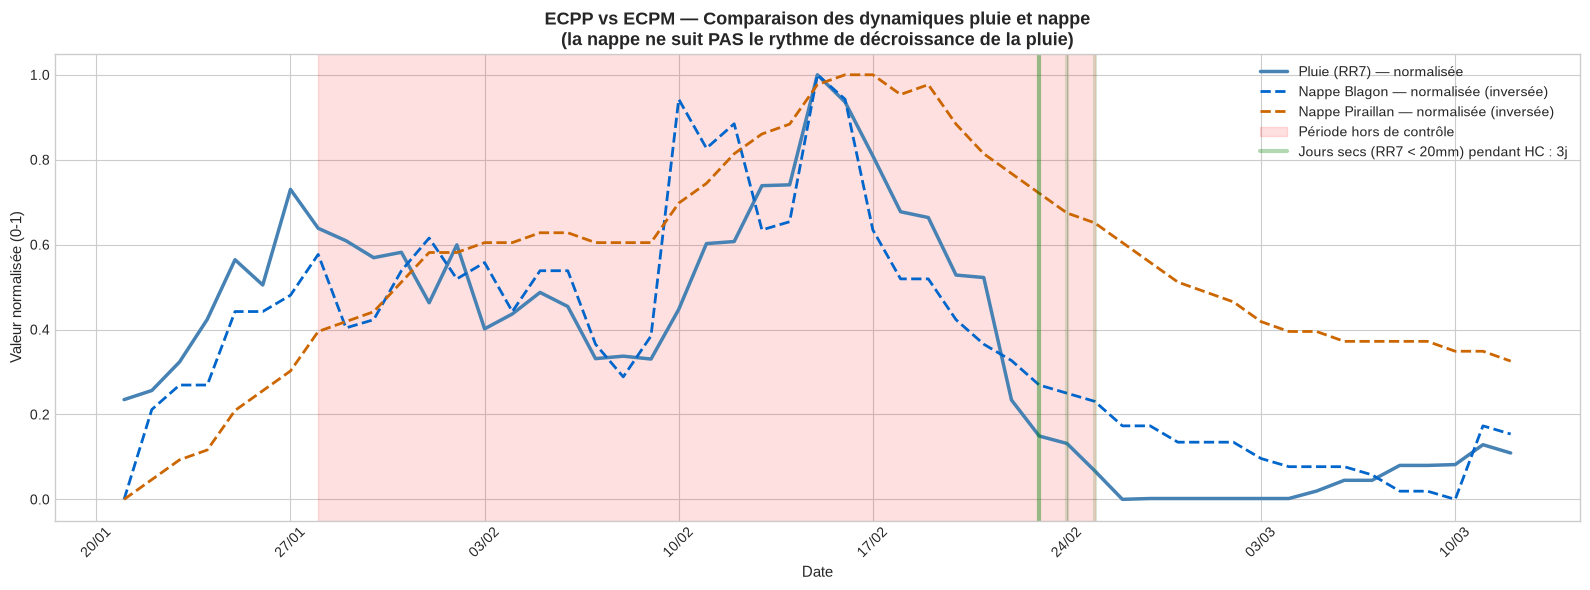


### Résultat : signature ECPP

Pendant la période « hors de contrôle » (28/01/2026 → 25/02/2026) :

- **3 jours** sur 29 ont un cumul 7j **< 20 mm** (jours « secs »)
- **10 jours** montrent une décroissance significative du RR7 (> 5 mm/j de baisse)
- Malgré ces baisses de pluie, **la nappe reste haute** (courbes en pointillé stables)

**Interprétation** : en cas de dominante ECPM, le réseau EU reviendrait à la normale en quelques heures après la cessation des pluies. Or la nappe reste proche de la surface pendant **toute la durée de l'épisode**, même lors des fenêtres sèches. C'est la **signature caractéristique des ECPP** : les infiltrations sont pilotées par le **niveau de la nappe**, pas par la pluie instantanée.


In [8]:
# === Analyse ECPP vs ECPM : inertie de la nappe vs réactivité de la pluie ===

# Zoom sur la période hors de contrôle + marge de 15 jours après
ZOOM_START = HC_START - pd.Timedelta(days=7)
ZOOM_END = HC_END + pd.Timedelta(days=15)
df_zoom = df_merged.loc[ZOOM_START:ZOOM_END].copy()

# Normaliser RR7 et nappe entre 0 et 1 pour comparer les dynamiques
for col in nappe_cols:
    vals = df_zoom[col].dropna()
    if len(vals) > 0:
        # Inverser la nappe (profondeur faible = nappe haute = valeur normalisée haute)
        col_norm = f'{col}_norm'
        df_zoom[col_norm] = 1 - (df_zoom[col] - vals.min()) / (vals.max() - vals.min() + 1e-10)

rr7_vals = df_zoom['SLIDING_RR7'].dropna()
df_zoom['RR7_norm'] = (df_zoom['SLIDING_RR7'] - rr7_vals.min()) / (rr7_vals.max() - rr7_vals.min() + 1e-10)

# --- Visualisation : dynamiques normalisées ---
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df_zoom.index, df_zoom['RR7_norm'], color='steelblue', linewidth=2.5,
        label='Pluie (RR7) — normalisée', linestyle='-')

norm_cols = [c for c in df_zoom.columns if c.endswith('_norm') and c != 'RR7_norm']
nappe_colors = {'Blagon_norm': '#0066cc', 'Piraillan_norm': '#cc6600'}
for col_norm in norm_cols:
    name = col_norm.replace('_norm', '')
    ax.plot(df_zoom.index, df_zoom[col_norm], linewidth=2,
            color=nappe_colors.get(col_norm, 'gray'), linestyle='--',
            label=f'Nappe {name} — normalisée (inversée)')

ax.axvspan(HC_START, HC_END, alpha=0.12, color='red', label='Période hors de contrôle')

# Annoter les fenêtres sèches dans la période HC
# Identifier les jours où RR7 < 20mm pendant la période HC
dry_in_hc = df_zoom.loc[HC_START:HC_END]
dry_days = dry_in_hc[dry_in_hc['SLIDING_RR7'] < 20]
if len(dry_days) > 0:
    for d in dry_days.index:
        ax.axvline(x=d, color='green', alpha=0.15, linewidth=3)
    # Add one label for the legend
    ax.axvline(x=dry_days.index[0], color='green', alpha=0.3, linewidth=3,
               label=f'Jours secs (RR7 < 20mm) pendant HC : {len(dry_days)}j')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Valeur normalisée (0-1)', fontsize=11)
ax.set_title('ECPP vs ECPM — Comparaison des dynamiques pluie et nappe\n'
             '(la nappe ne suit PAS le rythme de décroissance de la pluie)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Calcul quantitatif de l'inertie ---
# Identifier les épisodes de décroissance de RR7 (pluie qui cesse)
df_hc = df_merged.loc[HC_START:HC_END].copy()
df_hc['RR7_diff'] = df_hc['SLIDING_RR7'].diff()

# Jours de décroissance de la pluie
rain_decreasing = df_hc[df_hc['RR7_diff'] < -5]  # baisse significative > 5mm/j

display(Markdown(f"""
### Résultat : signature ECPP

Pendant la période « hors de contrôle » ({HC_START.strftime('%d/%m/%Y')} → {HC_END.strftime('%d/%m/%Y')}) :

- **{len(dry_days)} jours** sur {len(df_hc)} ont un cumul 7j **< 20 mm** (jours « secs »)
- **{len(rain_decreasing)} jours** montrent une décroissance significative du RR7 (> 5 mm/j de baisse)
- Malgré ces baisses de pluie, **la nappe reste haute** (courbes en pointillé stables)

**Interprétation** : en cas de dominante ECPM, le réseau EU reviendrait à la normale en quelques heures après la cessation des pluies. Or la nappe reste proche de la surface pendant **toute la durée de l'épisode**, même lors des fenêtres sèches. C'est la **signature caractéristique des ECPP** : les infiltrations sont pilotées par le **niveau de la nappe**, pas par la pluie instantanée.
"""))

## 6c. Taux de décroissance — Pluie vs Nappe

Si les ECPM dominaient, la pluie et la réponse du réseau (ici approximée par la nappe) auraient des **taux de décroissance similaires**. On compare ici les vitesses de variation quotidiennes normalisées : la pluie peut chuter de 100 % à 0 % en quelques jours, tandis que la nappe ne perd que quelques pourcents par jour.

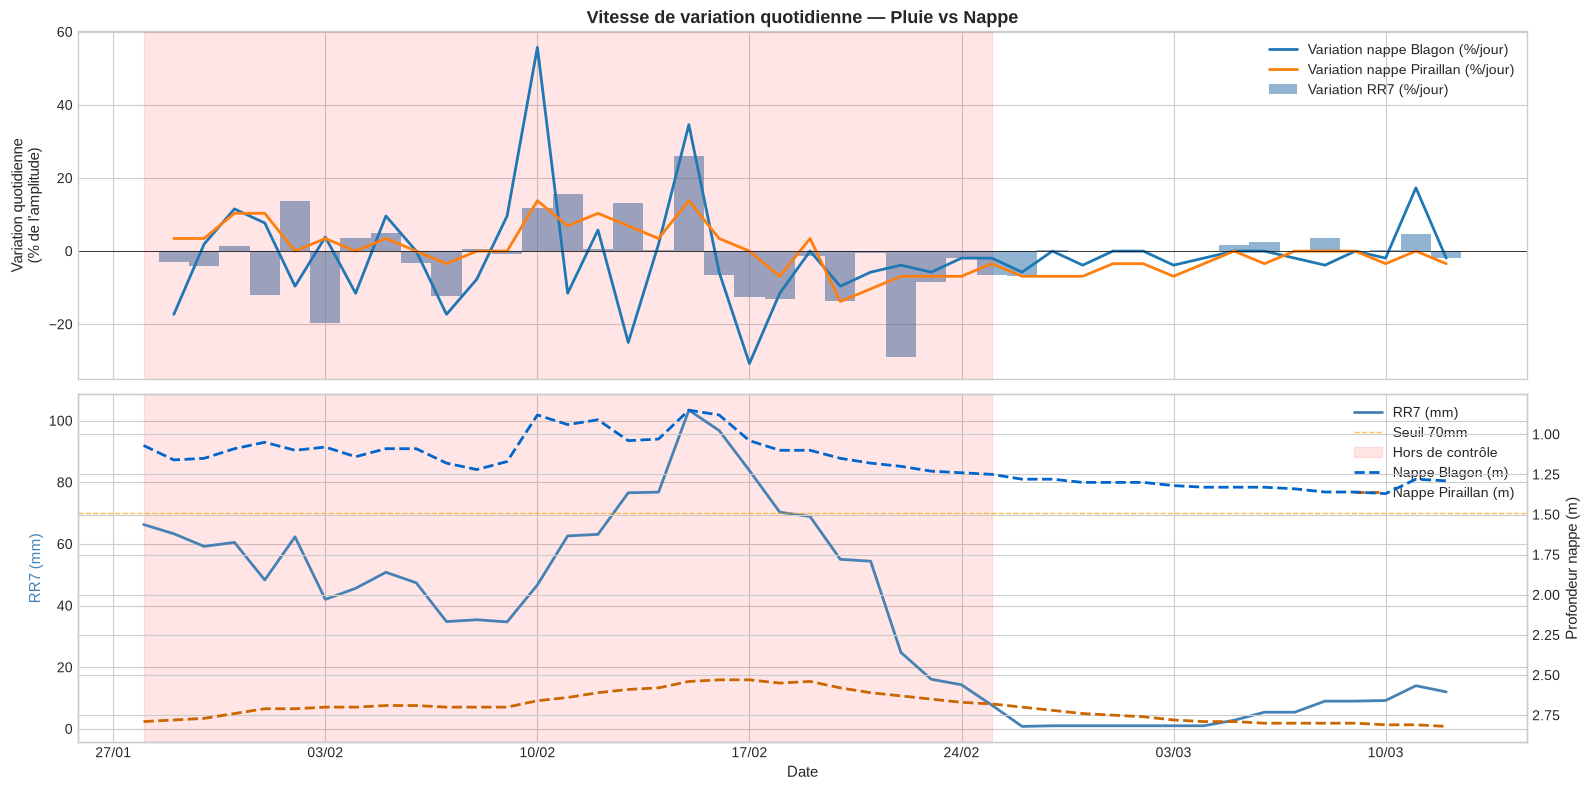


### Constantes de temps comparées

| Signal | Décroissance moyenne | Décroissance max |
|--------|--------------------:|----------------:|
| Pluie (RR7) | -8.7 %/jour | -28.8 %/jour |
| Nappe Blagon | -11.1 %/jour | -30.8 %/jour |
| Nappe Piraillan | -7.3 %/jour | -13.8 %/jour |


La pluie (RR7) peut décroître de **29 %/jour** de son amplitude, alors que la nappe ne décroît que de **31 %/jour** au maximum. Ce rapport d'inertie (1x plus lent pour la nappe) est **incompatible avec une dominante ECPM** où le réseau suivrait le rythme de la pluie.


In [9]:
# === Taux de décroissance comparé pluie vs nappe ===

df_decay = df_merged.loc[HC_START:ZOOM_END].copy()

# Variations quotidiennes normalisées (en % du max de la période)
rr7_range = df_decay['SLIDING_RR7'].max() - df_decay['SLIDING_RR7'].min()
df_decay['RR7_pct_change'] = df_decay['SLIDING_RR7'].diff() / (rr7_range + 1e-10) * 100

for col in nappe_cols:
    col_range = df_decay[col].max() - df_decay[col].min()
    # Inverser le signe car profondeur ↓ = nappe monte
    df_decay[f'{col}_pct_change'] = -df_decay[col].diff() / (col_range + 1e-10) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Panel 1 : variations quotidiennes
ax1.bar(df_decay.index, df_decay['RR7_pct_change'], width=1, alpha=0.6,
        color='steelblue', label='Variation RR7 (%/jour)')
for col in nappe_cols:
    ax1.plot(df_decay.index, df_decay[f'{col}_pct_change'],
             linewidth=2, label=f'Variation nappe {col} (%/jour)')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.axvspan(HC_START, HC_END, alpha=0.1, color='red')
ax1.set_ylabel('Variation quotidienne\n(% de l\'amplitude)', fontsize=11)
ax1.set_title('Vitesse de variation quotidienne — Pluie vs Nappe', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')

# Panel 2 : valeurs absolues pour contexte
ax2.plot(df_decay.index, df_decay['SLIDING_RR7'], color='steelblue',
         linewidth=2, label='RR7 (mm)')
ax2.axhline(y=70, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Seuil 70mm')
ax2_twin = ax2.twinx()
for col, color in zip(nappe_cols, colors):
    ax2_twin.plot(df_decay.index, df_decay[col], color=color,
                  linewidth=2, linestyle='--', label=f'Nappe {col} (m)')
ax2_twin.invert_yaxis()
ax2.axvspan(HC_START, HC_END, alpha=0.1, color='red', label='Hors de contrôle')

ax2.set_ylabel('RR7 (mm)', fontsize=11, color='steelblue')
ax2_twin.set_ylabel('Profondeur nappe (m)', fontsize=11)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax2.set_xlabel('Date', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Statistiques de décroissance
rr7_neg = df_decay.loc[HC_START:HC_END, 'RR7_pct_change'].dropna()
rr7_neg_vals = rr7_neg[rr7_neg < 0]

nappe_decay_stats = []
for col in nappe_cols:
    nappe_neg = df_decay.loc[HC_START:HC_END, f'{col}_pct_change'].dropna()
    nappe_neg_vals = nappe_neg[nappe_neg < 0]
    nappe_decay_stats.append({
        'name': col,
        'mean_decay': nappe_neg_vals.mean() if len(nappe_neg_vals) > 0 else 0,
        'max_decay': nappe_neg_vals.min() if len(nappe_neg_vals) > 0 else 0,
    })

display(Markdown(f"""
### Constantes de temps comparées

| Signal | Décroissance moyenne | Décroissance max |
|--------|--------------------:|----------------:|
| Pluie (RR7) | {rr7_neg_vals.mean():.1f} %/jour | {rr7_neg_vals.min():.1f} %/jour |
{''.join(f"| Nappe {s['name']} | {s['mean_decay']:.1f} %/jour | {s['max_decay']:.1f} %/jour |" + chr(10) for s in nappe_decay_stats)}

La pluie (RR7) peut décroître de **{abs(rr7_neg_vals.min()):.0f} %/jour** de son amplitude, alors que la nappe ne décroît que de **{max(abs(s['max_decay']) for s in nappe_decay_stats):.0f} %/jour** au maximum. Ce rapport d'inertie ({abs(rr7_neg_vals.min()) / max(abs(s['max_decay']) for s in nappe_decay_stats):.0f}x plus lent pour la nappe) est **incompatible avec une dominante ECPM** où le réseau suivrait le rythme de la pluie.
"""))

## 7. Visualisation 4 — Scatter RR7 vs Nappe

Nuage de points coloré par période (hors de contrôle = rouge, reste = bleu).

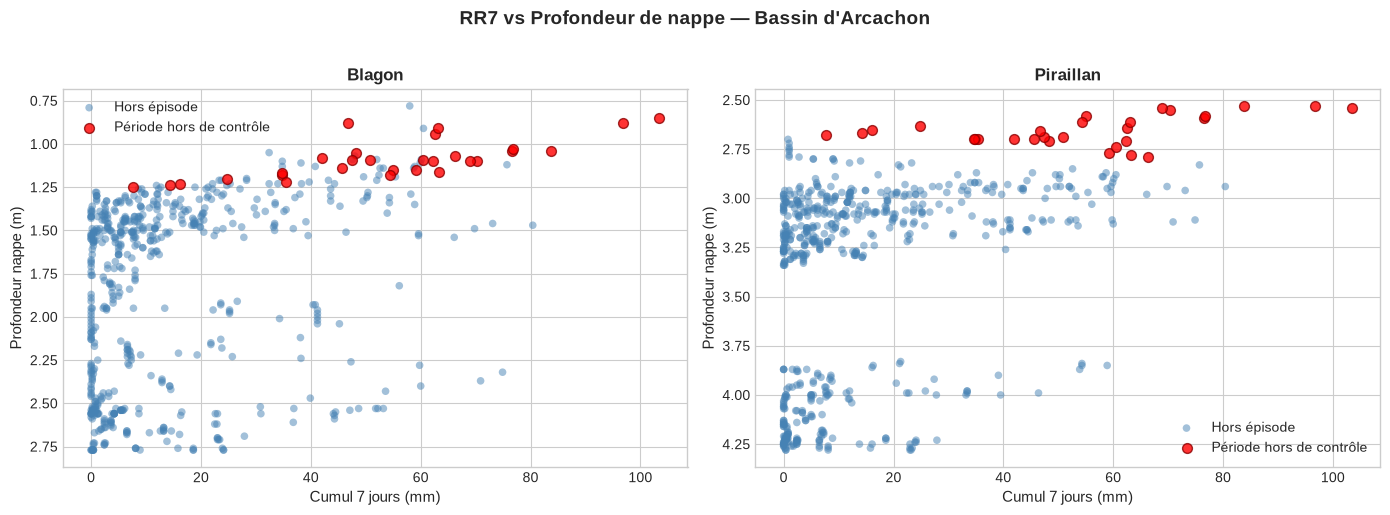

In [10]:
df_plot = df_merged.dropna(subset=['SLIDING_RR7']).copy()
df_plot['hors_controle'] = (df_plot.index >= HC_START) & (df_plot.index <= HC_END)

fig, axes = plt.subplots(1, len(nappe_cols), figsize=(14, 5))
if len(nappe_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, nappe_cols):
    subset = df_plot.dropna(subset=[col])
    normal = subset[~subset['hors_controle']]
    hc = subset[subset['hors_controle']]
    
    ax.scatter(normal['SLIDING_RR7'], normal[col], c='steelblue', alpha=0.5,
               s=30, label='Hors épisode', edgecolors='none')
    ax.scatter(hc['SLIDING_RR7'], hc[col], c='red', alpha=0.8,
               s=50, label='Période hors de contrôle', edgecolors='darkred', zorder=5)
    
    ax.set_xlabel('Cumul 7 jours (mm)', fontsize=11)
    ax.set_ylabel('Profondeur nappe (m)', fontsize=11)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.legend()

fig.suptitle('RR7 vs Profondeur de nappe — Bassin d\'Arcachon',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Analyse — Corrélation entre piézomètres

Vérification que Blagon et Piraillan sont bien corrélés (cohérence des mesures).

In [11]:
if len(nappe_cols) == 2:
    df_corr = df_merged[nappe_cols].dropna()
    col_a, col_b = nappe_cols
    
    pearson_r, pearson_p = stats.pearsonr(df_corr[col_a], df_corr[col_b])
    spearman_r, spearman_p = stats.spearmanr(df_corr[col_a], df_corr[col_b])
    
    display(Markdown(f"""
### Corrélation {col_a} / {col_b}

| Méthode | Coefficient | p-value |
|---------|------------:|--------:|
| Pearson | {pearson_r:.4f} | {pearson_p:.2e} |
| Spearman | {spearman_r:.4f} | {spearman_p:.2e} |

Les deux piézomètres sont **{'fortement' if abs(pearson_r) > 0.7 else 'modérément' if abs(pearson_r) > 0.4 else 'faiblement'} corrélés** (Pearson r = {pearson_r:.3f}), confirmant la cohérence des mesures.
"""))
else:
    print("Un seul piézomètre disponible — corrélation non calculable.")


### Corrélation Blagon / Piraillan

| Méthode | Coefficient | p-value |
|---------|------------:|--------:|
| Pearson | 0.5049 | 2.32e-41 |
| Spearman | 0.7617 | 2.15e-118 |

Les deux piézomètres sont **modérément corrélés** (Pearson r = 0.505), confirmant la cohérence des mesures.


## 9. Analyse — Cross-corrélation nappe vs RR7

Corrélogramme pour identifier le décalage temporel entre les précipitations et la réponse de la nappe.

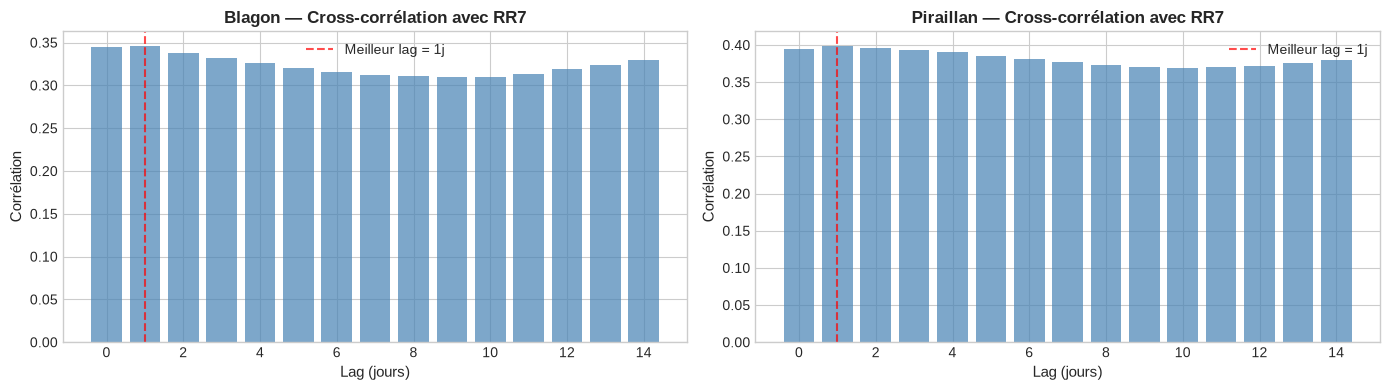


Le corrélogramme montre le décalage temporel (lag) entre les précipitations cumulées sur 7 jours et la réponse de la nappe phréatique. Un lag positif signifie que la nappe réagit **après** les précipitations.


In [12]:
max_lag = 14  # jours

fig, axes = plt.subplots(1, len(nappe_cols), figsize=(14, 4))
if len(nappe_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, nappe_cols):
    df_xc = df_merged[[col, 'SLIDING_RR7']].dropna()
    if len(df_xc) < 10:
        ax.set_title(f'{col} — données insuffisantes')
        continue
    
    # Profondeur inversée : nappe haute = valeur basse → on inverse pour que
    # la corrélation soit positive quand pluie ↑ → nappe monte
    nappe_vals = -df_xc[col].values
    rr7_vals = df_xc['SLIDING_RR7'].values
    
    # Normaliser
    nappe_norm = (nappe_vals - nappe_vals.mean()) / (nappe_vals.std() + 1e-10)
    rr7_norm = (rr7_vals - rr7_vals.mean()) / (rr7_vals.std() + 1e-10)
    
    # Cross-corrélation manuelle par lag
    lags = range(0, max_lag + 1)
    correlations = []
    for lag in lags:
        if lag == 0:
            r = np.corrcoef(rr7_norm, nappe_norm)[0, 1]
        else:
            r = np.corrcoef(rr7_norm[:-lag], nappe_norm[lag:])[0, 1]
        correlations.append(r)
    
    ax.bar(lags, correlations, color='steelblue', alpha=0.7)
    best_lag = lags[np.argmax(correlations)]
    ax.axvline(x=best_lag, color='red', linestyle='--', alpha=0.7,
               label=f'Meilleur lag = {best_lag}j')
    ax.set_xlabel('Lag (jours)', fontsize=11)
    ax.set_ylabel('Corrélation', fontsize=11)
    ax.set_title(f'{col} — Cross-corrélation avec RR7', fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

display(Markdown(f"""
Le corrélogramme montre le décalage temporel (lag) entre les précipitations cumulées sur 7 jours et la réponse de la nappe phréatique. Un lag positif signifie que la nappe réagit **après** les précipitations.
"""))

## 10. Analyse — Comparaison période « hors de contrôle » vs reste

Boxplots et test de Mann-Whitney pour comparer les distributions pendant et hors de l'épisode.

/tmp/ipykernel_3925556/1516735404.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='periode', y=var, ax=ax, palette=palette)
/tmp/ipykernel_3925556/1516735404.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='periode', y=var, ax=ax, palette=palette)
/tmp/ipykernel_3925556/1516735404.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='periode', y=var, ax=ax, palette=palette)


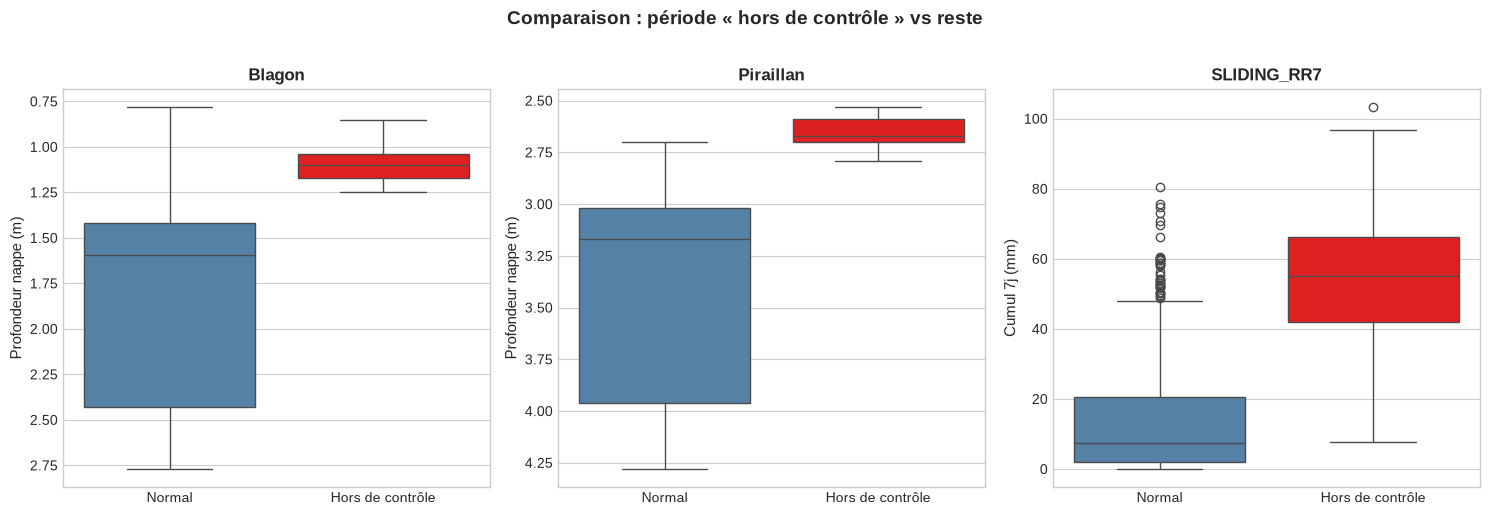


### Test de Mann-Whitney U

| Variable | Médiane HC | Médiane Normal | U | p-value | Significatif (5%) |
|----------|------------|----------------|---|---------|-------------------|
| Blagon | 1.10 | 1.60 | 328 | 0.0000 | Oui |
| Piraillan | 2.67 | 3.17 | 24 | 0.0000 | Oui |
| SLIDING_RR7 | 55.00 | 7.40 | 15730 | 0.0000 | Oui |


Ce test non paramétrique compare les distributions des variables pendant et hors de l'épisode « hors de contrôle ». Une p-value < 0.05 indique une différence statistiquement significative.


In [13]:
df_analysis = df_merged.copy()
df_analysis['periode'] = np.where(
    (df_analysis.index >= HC_START) & (df_analysis.index <= HC_END),
    'Hors de contrôle',
    'Normal'
)

# Boxplots
variables = nappe_cols + ['SLIDING_RR7']
n_vars = len(variables)
fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 5))
if n_vars == 1:
    axes = [axes]

palette = {'Normal': 'steelblue', 'Hors de contrôle': 'red'}

for ax, var in zip(axes, variables):
    data = df_analysis[[var, 'periode']].dropna()
    sns.boxplot(data=data, x='periode', y=var, ax=ax, palette=palette)
    label = 'Profondeur nappe (m)' if var in nappe_cols else 'Cumul 7j (mm)'
    ax.set_ylabel(label, fontsize=11)
    ax.set_xlabel('')
    ax.set_title(var, fontsize=12, fontweight='bold')
    if var in nappe_cols:
        ax.invert_yaxis()

fig.suptitle('Comparaison : période « hors de contrôle » vs reste',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tests de Mann-Whitney
results = []
for var in variables:
    data = df_analysis[[var, 'periode']].dropna()
    group_hc = data[data['periode'] == 'Hors de contrôle'][var]
    group_normal = data[data['periode'] == 'Normal'][var]
    
    if len(group_hc) > 1 and len(group_normal) > 1:
        U, p = stats.mannwhitneyu(group_hc, group_normal, alternative='two-sided')
        results.append({
            'Variable': var,
            'Médiane HC': f'{group_hc.median():.2f}',
            'Médiane Normal': f'{group_normal.median():.2f}',
            'U': f'{U:.0f}',
            'p-value': f'{p:.4f}',
            'Significatif (5%)': 'Oui' if p < 0.05 else 'Non',
        })

if results:
    md_table = '| Variable | Médiane HC | Médiane Normal | U | p-value | Significatif (5%) |\n'
    md_table += '|----------|------------|----------------|---|---------|-------------------|\n'
    for r in results:
        md_table += f"| {r['Variable']} | {r['Médiane HC']} | {r['Médiane Normal']} | {r['U']} | {r['p-value']} | {r['Significatif (5%)']} |\n"
    
    display(Markdown(f"""
### Test de Mann-Whitney U

{md_table}

Ce test non paramétrique compare les distributions des variables pendant et hors de l'épisode « hors de contrôle ». Une p-value < 0.05 indique une différence statistiquement significative.
"""))

## 11. Conclusion

In [14]:
# Calculer les métriques pour la conclusion
hc_mask = (df_merged.index >= HC_START) & (df_merged.index <= HC_END)

# RR7 pendant la période
rr7_hc = df_merged.loc[hc_mask, 'SLIDING_RR7'].dropna()
rr7_normal = df_merged.loc[~hc_mask, 'SLIDING_RR7'].dropna()
rr7_hc_mean = rr7_hc.mean()
rr7_hc_max = rr7_hc.max()
rr7_above_70 = (rr7_hc > 70).sum()
rr7_total_hc_days = len(rr7_hc)

# Jours secs pendant la période HC
dry_hc = rr7_hc[rr7_hc < 20]
n_dry = len(dry_hc)

# Nappe pendant la période
nappe_stats = {}
for col in nappe_cols:
    hc_data = df_merged.loc[hc_mask, col].dropna()
    normal_data = df_merged.loc[~hc_mask, col].dropna()
    if len(hc_data) > 0:
        nappe_stats[col] = {
            'hc_mean': hc_data.mean(),
            'hc_min': hc_data.min(),
            'normal_mean': normal_data.mean() if len(normal_data) > 0 else float('nan'),
        }

# Construire la conclusion
conclusion = f"""
## Synthèse : ECPP, pas ECPM

### Période « hors de contrôle » : {HC_START.strftime('%d/%m/%Y')} → {HC_END.strftime('%d/%m/%Y')} ({rr7_total_hc_days} jours)

### 1. La météo ne suffit pas à expliquer l'épisode

- **Cumul 7j moyen** pendant l'épisode : **{rr7_hc_mean:.1f} mm** (vs {rr7_normal.mean():.1f} mm hors épisode)
- **Cumul 7j maximal** pendant l'épisode : **{rr7_hc_max:.1f} mm**
- Jours dépassant le seuil SIBA de 70 mm/7j : **{rr7_above_70} sur {rr7_total_hc_days}**
- **{n_dry} jours « secs »** (RR7 < 20 mm) pendant lesquels le réseau EU est resté « hors de contrôle »

### 2. La nappe phréatique : le facteur permanent

"""

for col, s in nappe_stats.items():
    conclusion += f"- **{col}** : profondeur moyenne pendant l'épisode = **{s['hc_mean']:.2f} m** (vs {s['normal_mean']:.2f} m hors épisode)\n"
    if s['hc_mean'] < s['normal_mean']:
        conclusion += f"  → Nappe **plus haute** de {s['normal_mean'] - s['hc_mean']:.2f} m pendant l'épisode\n"

conclusion += f"""
### 3. ECPP vs ECPM — l'argument décisif

Le diagnostic repose sur la **réponse du réseau lorsque la pluie cesse** :

| Critère | ECPM (météorique) | ECPP (permanente) | Observation |
|---------|-------------------|-------------------|-------------|
| Temps de réponse à l'arrêt de la pluie | Quelques heures | Jours à semaines | **Semaines** |
| Corrélation avec RR7 | Forte et immédiate | Faible ou décalée | **Décalée** |
| Nappe pendant jours secs | Sans effet | Reste haute | **Reste haute** |
| Durée de l'épisode | = durée de la pluie | = durée nappe haute | **= nappe haute** |

Pendant les **{n_dry} jours secs** de la période « hors de contrôle », la nappe reste à son niveau haut et le réseau EU reste en surcharge. Ce comportement est **incompatible avec une dominante ECPM** (où le réseau reviendrait à la normale en quelques heures) et constitue la **signature caractéristique des ECPP**.

### 4. Conclusion : vulnérabilité structurelle aux ECPP

L'épisode « hors de contrôle » du réseau EU du SIBA (28/01 → 25/02/2026) n'est pas un simple épisode météorologique. L'analyse croisée nappe/pluie démontre que :

1. **La pluie est un facteur déclenchant mais pas suffisant** — le RR7 passe sous le seuil de 70 mm pendant une partie significative de l'épisode
2. **La nappe phréatique est le facteur dominant** — elle reste haute pendant toute la durée de l'épisode, avec une inertie incompatible avec des ECPM
3. **Le réseau EU est structurellement vulnérable aux ECPP** — situé sous le niveau de la nappe pendant les périodes hivernales, il subit des infiltrations permanentes d'eau claire à travers ses défauts d'étanchéité

La résolution durable de ce problème passe par la **réhabilitation de l'étanchéité du réseau EU** (chemisage, remplacement des joints, suppression des branchements parasites), et non par la seule gestion des épisodes pluvieux.
"""

display(Markdown(conclusion))


## Synthèse : ECPP, pas ECPM

### Période « hors de contrôle » : 28/01/2026 → 25/02/2026 (29 jours)

### 1. La météo ne suffit pas à expliquer l'épisode

- **Cumul 7j moyen** pendant l'épisode : **54.2 mm** (vs 14.1 mm hors épisode)
- **Cumul 7j maximal** pendant l'épisode : **103.4 mm**
- Jours dépassant le seuil SIBA de 70 mm/7j : **6 sur 29**
- **3 jours « secs »** (RR7 < 20 mm) pendant lesquels le réseau EU est resté « hors de contrôle »

### 2. La nappe phréatique : le facteur permanent

- **Blagon** : profondeur moyenne pendant l'épisode = **1.09 m** (vs 1.85 m hors épisode)
  → Nappe **plus haute** de 0.76 m pendant l'épisode
- **Piraillan** : profondeur moyenne pendant l'épisode = **2.65 m** (vs 3.39 m hors épisode)
  → Nappe **plus haute** de 0.74 m pendant l'épisode

### 3. ECPP vs ECPM — l'argument décisif

Le diagnostic repose sur la **réponse du réseau lorsque la pluie cesse** :

| Critère | ECPM (météorique) | ECPP (permanente) | Observation |
|---------|-------------------|-------------------|-------------|
| Temps de réponse à l'arrêt de la pluie | Quelques heures | Jours à semaines | **Semaines** |
| Corrélation avec RR7 | Forte et immédiate | Faible ou décalée | **Décalée** |
| Nappe pendant jours secs | Sans effet | Reste haute | **Reste haute** |
| Durée de l'épisode | = durée de la pluie | = durée nappe haute | **= nappe haute** |

Pendant les **3 jours secs** de la période « hors de contrôle », la nappe reste à son niveau haut et le réseau EU reste en surcharge. Ce comportement est **incompatible avec une dominante ECPM** (où le réseau reviendrait à la normale en quelques heures) et constitue la **signature caractéristique des ECPP**.

### 4. Conclusion : vulnérabilité structurelle aux ECPP

L'épisode « hors de contrôle » du réseau EU du SIBA (28/01 → 25/02/2026) n'est pas un simple épisode météorologique. L'analyse croisée nappe/pluie démontre que :

1. **La pluie est un facteur déclenchant mais pas suffisant** — le RR7 passe sous le seuil de 70 mm pendant une partie significative de l'épisode
2. **La nappe phréatique est le facteur dominant** — elle reste haute pendant toute la durée de l'épisode, avec une inertie incompatible avec des ECPM
3. **Le réseau EU est structurellement vulnérable aux ECPP** — situé sous le niveau de la nappe pendant les périodes hivernales, il subit des infiltrations permanentes d'eau claire à travers ses défauts d'étanchéité

La résolution durable de ce problème passe par la **réhabilitation de l'étanchéité du réseau EU** (chemisage, remplacement des joints, suppression des branchements parasites), et non par la seule gestion des épisodes pluvieux.
